In [7]:
#install
%pip install librosa

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 3.6 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [soundfile]
   -------------------- ------------------- 2/4 [pooch]
   ------------------------------ --------- 3/4 [librosa]
   ------------------------------ --------- 3/4 [librosa]
   ------------------------------ --------- 3/4 [librosa]
   ------------------------------ --------- 3/4 [librosa]
   ------------------------------ --------- 3/4 [librosa]
   ---------------------------------------- 4/4 [librosa]

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
#modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
import librosa 
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Scan dataset directory, collect all .wav file paths, and extract emotion labels from filenames
data_dir = r'C:\Users\Admin\Documents\Deep Learning Project\TESS Toronto emotional speech set data'
print("Path exists:", os.path.exists(data_dir))

paths = []
labels = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith('.wav'):
            paths.append(os.path.join(root, file))
            label = file.split('_')[-1].split('.')[0].lower()
            labels.append(label)

Path exists: True


In [4]:
# Convert paths and labels into a Pandas DataFrame
speech = pd.DataFrame({'speech': paths,
                      'label' : labels})
print(f"Total files: {len(speech)}")
speech.head()

Total files: 2800


,speech,label
0,C:\Users\Admin\Documents\Deep Learning Project...,angry
1,C:\Users\Admin\Documents\Deep Learning Project...,angry
2,C:\Users\Admin\Documents\Deep Learning Project...,angry
3,C:\Users\Admin\Documents\Deep Learning Project...,angry
4,C:\Users\Admin\Documents\Deep Learning Project...,angry


In [5]:
speech['label'].value_counts()

label
angry      400
disgust    400
fear       400
happy      400
neutral    400
ps         400
sad        400
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

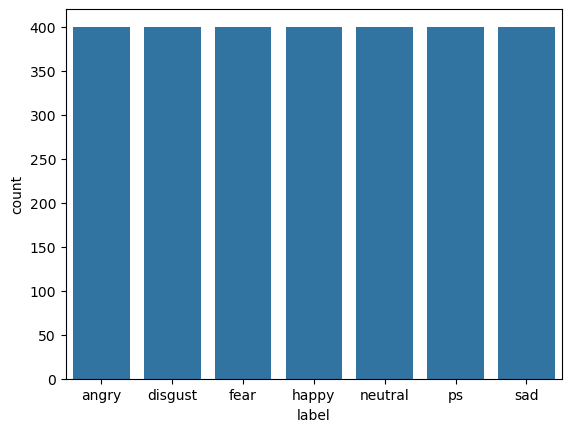

In [6]:
sns.countplot(data=speech, x='label')

In [8]:
# Extract MFCC audio features from each file and reshape them into a 3D array for deep learning models
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

X_mfcc = speech['speech'].apply(lambda x: extract_mfcc(x))
X = np.array([x for x in X_mfcc])
X = np.expand_dims(X,-1)

print("Input shape ready for model:", X.shape)

Input shape ready for model: (2800, 40, 1)


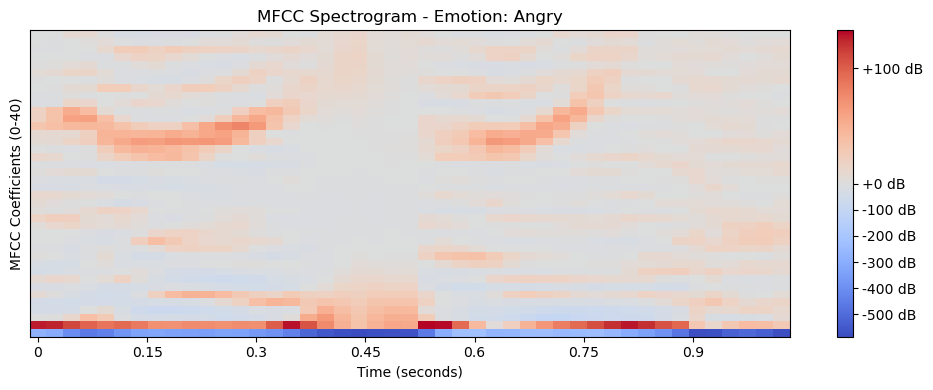

In [9]:
# 1. Pick a sample file from your DataFrame
sample_path = speech['speech'].iloc[0]
sample_label = speech['label'].iloc[0]

# 2. Load the audio clip
y, sr = librosa.load(sample_path, duration=3, offset=0.5)

# 3. Compute MFCCs (keep time steps intact for visualization)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

# 4. Plot the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, sr=sr, x_axis='time')

plt.colorbar(format='%+2.0f dB')
plt.title(f"MFCC Spectrogram - Emotion: {sample_label.capitalize()}")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficients (0-40)")
plt.tight_layout()
plt.show()

In [10]:
# Convert text emotion labels into a one-hot encoded binary matrix (0s and 1s) for neural network targets
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
y = encoder.fit_transform(speech[['label']]).toarray()

print("Encoded Target Shape:", y.shape)  # Expected: (2800, 7)
print("Detected Emotion Classes:", encoder.categories_[0])

Encoded Target Shape: (2800, 7)
Detected Emotion Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [11]:
# Split features and labels into 80% training and 20% testing sets while keeping emotion class proportions balanced
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify = y
)

print("Training features shape:", X_train.shape)  # Expected: (2240, 40, 1)
print("Testing features shape: ", X_test.shape)  # Expected: (560, 40, 1)

Training features shape: (2240, 40, 1)
Testing features shape:  (560, 40, 1)


In [12]:
# 1. Build an LSTM neural network to analyze time-sequence patterns in the 40 MFCC audio features
# 2. Add Dense layers with Dropout (20%) to refine learned patterns and prevent overfitting
# 3. Compile the model with Adam optimizer and Softmax activation for multi-class emotion classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(128, input_shape=(40, 1), return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(y.shape[1], activation='softmax'),
])

model.compile(
    loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 128)                 │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,127 (301.28 KB)

 Trainable params: 77,127 (301.28 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 1. Train the model for 50 full passes (epochs) over the training dataset
# 2. Process data in mini-batches of 64 samples and shuffle order each epoch
# 3. Evaluate loss and accuracy on the validation set (X_test, y_test) after every pass
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    shuffle=True,
)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.4018 - loss: 1.5219 - val_accuracy: 0.6143 - val_loss: 0.9302
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6839 - loss: 0.7909 - val_accuracy: 0.8607 - val_loss: 0.4185
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8589 - loss: 0.4173 - val_accuracy: 0.8821 - val_loss: 0.3396
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9192 - loss: 0.2545 - val_accuracy: 0.9482 - val_loss: 0.1885
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9397 - loss: 0.2056 - val_accuracy: 0.9446 - val_loss: 0.1985
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9554 - loss: 0.1588 - val_accuracy: 0.9571 - val_loss: 0.1454
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9576 - loss: 0.1490 - val_accuracy: 0.9625 - val_loss: 0.1299
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9661 - loss: 0.1182 - val_accuracy: 0.9607 - v

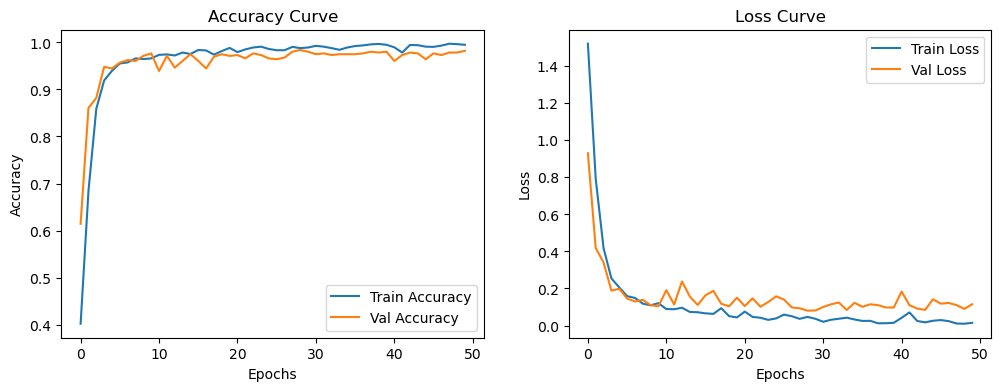

In [14]:
# Create side-by-side plots comparing training and validation accuracy and loss across all epochs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
=== Unseen Test Set Classification Report ===
              precision    recall  f1-score   support

       angry       0.96      0.97      0.97        80
     disgust       0.99      0.96      0.97        80
        fear       1.00      0.99      0.99        80
       happy       0.99      0.97      0.98        80
     neutral       0.98      1.00      0.99        80
          ps       0.96      0.99      0.98        80
         sad       1.00      0.99      0.99        80

    accuracy                           0.98       560
   macro avg       0.98      0.98      0.98       560
weighted avg       0.98      0.98      0.98       560



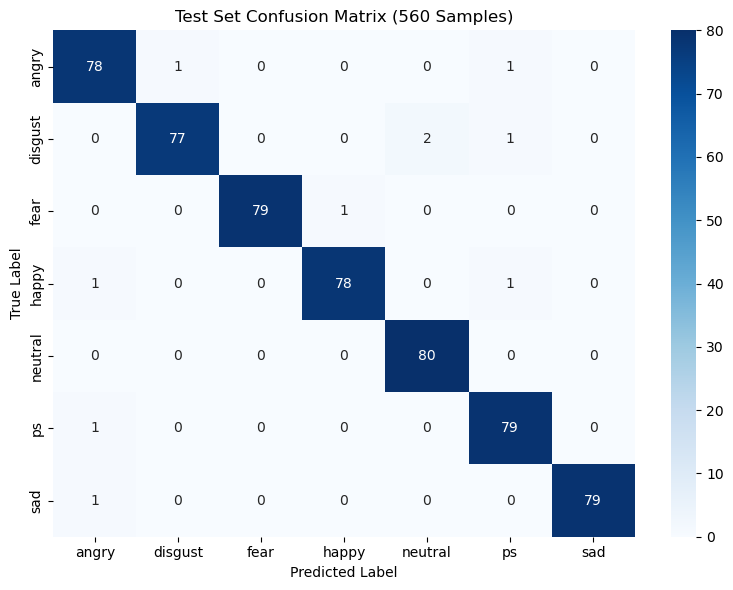

In [15]:
# Evaluate model performance on unseen test data using a detailed classification report and a visual confusion matrix heatmap
from sklearn.metrics import classification_report, confusion_matrix

# Predict on unseen test data only
y_pred_probs = model.predict(X_test)

# Convert one-hot vectors to index labels
y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(y_pred_probs, axis=1)

class_names = encoder.categories_[0]

# Print evaluation report
print("=== Unseen Test Set Classification Report ===")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Test Set Confusion Matrix (560 Samples)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [16]:
# Define a function to play an audio file inline, predict its emotion using the trained model, and plot a confidence bar chart
from IPython.display import Audio, display

def play_and_predict(audio_path, model, encoder):
    print("=" * 45)
    print("🔊 AUDIO PLAYER:")
    # 1. Display inline audio player widget
    display(Audio(filename=audio_path))
    
    # 2. Extract MFCC features
    y, sr = librosa.load(audio_path, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    features = np.expand_dims(mfcc, axis=(0, -1))
    
    # 3. Predict emotion probabilities
    predictions = model.predict(features, verbose=0)[0]
    class_idx = np.argmax(predictions)
    predicted_emotion = encoder.categories_[0][class_idx]
    confidence = predictions[class_idx] * 100
    
    # 4. Print core prediction result
    print(f"🎯 PREDICTED EMOTION: {predicted_emotion.upper()}")
    print(f"📊 CONFIDENCE SCORE:  {confidence:.2f}%")
    print("=" * 45)
    
    # 5. Optional: Display probability bar chart across all emotions
    plt.figure(figsize=(8, 3))
    emotions = encoder.categories_[0]
    plt.bar(emotions, predictions * 100, color='skyblue')
    plt.ylabel('Confidence (%)')
    plt.title('Emotion Probability Distribution')
    plt.xticks(rotation=30)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

Actual Ground Truth Label: HAPPY
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: HAPPY
📊 CONFIDENCE SCORE:  99.94%


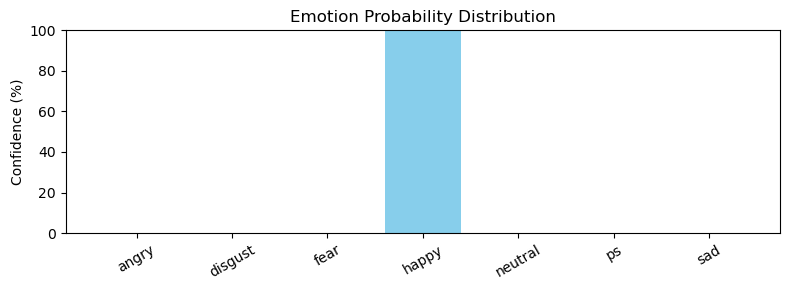

In [16]:
random_sample = speech.sample(1).iloc[0]

print(f"Actual Ground Truth Label: {random_sample['label'].upper()}")
play_and_predict(random_sample['speech'], model, encoder)


Target Emotion: ANGRY
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: ANGRY
📊 CONFIDENCE SCORE:  100.00%


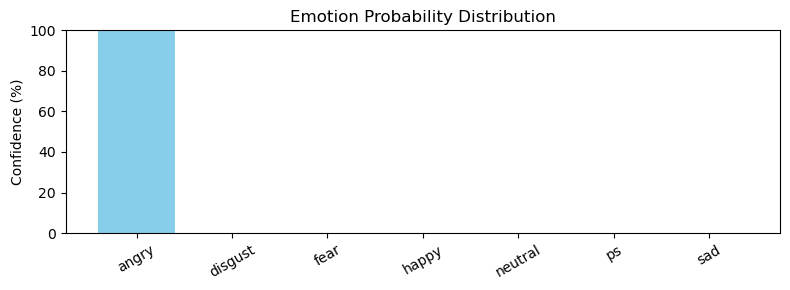


Target Emotion: DISGUST
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: DISGUST
📊 CONFIDENCE SCORE:  100.00%


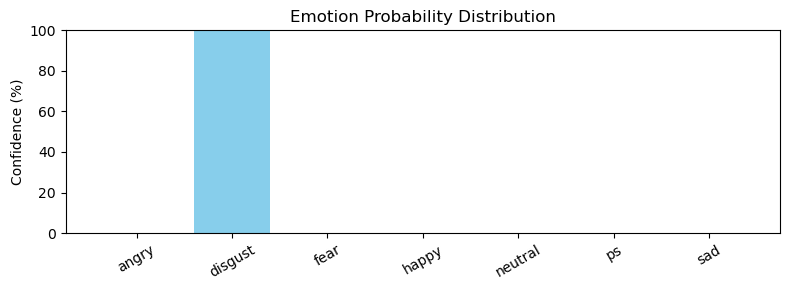


Target Emotion: FEAR
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: FEAR
📊 CONFIDENCE SCORE:  100.00%


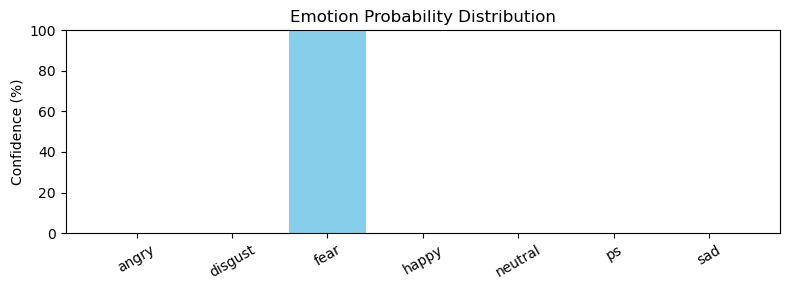


Target Emotion: HAPPY
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: HAPPY
📊 CONFIDENCE SCORE:  99.92%


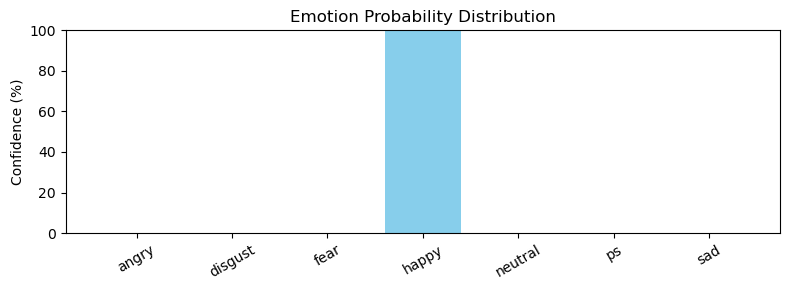


Target Emotion: NEUTRAL
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: NEUTRAL
📊 CONFIDENCE SCORE:  100.00%


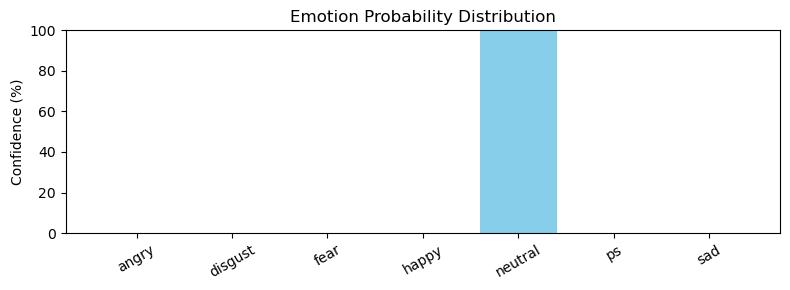


Target Emotion: PS
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: PS
📊 CONFIDENCE SCORE:  99.95%


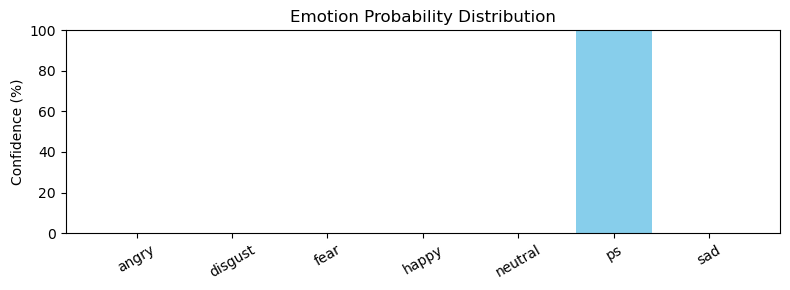


Target Emotion: SAD
🔊 AUDIO PLAYER:


🎯 PREDICTED EMOTION: SAD
📊 CONFIDENCE SCORE:  100.00%


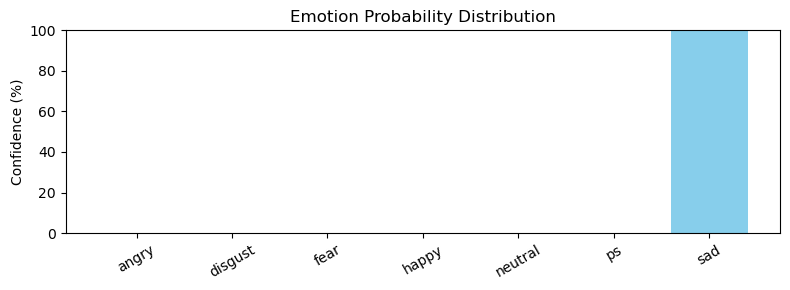

In [17]:
# Loop through each unique emotion class, randomly select a sample audio file, and test the model's prediction
for emotion_name in speech['label'].unique():
    sample = speech[speech['label'] == emotion_name].sample(50).iloc[0]
    print(f"\nTarget Emotion: {emotion_name.upper()}")
    play_and_predict(sample['speech'], model, encoder)

In [18]:
# Evaluate final training and testing accuracy numbers and run an overfitting check
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")

Training Accuracy: 99.33%
Testing Accuracy:  98.21%


In [20]:
# Calculate performance gap
acc_gap = (train_acc - test_acc) * 100
print(f"Accuracy Gap:      {acc_gap:.2f}%")


Accuracy Gap:      1.12%
